In [81]:
import matplotlib.pyplot as plt

import pandas as pd

====================================
LOAD AND PREPARE DATA

In [82]:
def load_data(filename):
    """
    Loads the spotify CSV and eturns a cleaned DataFrame.
    """

    df = pd.read_csv(filename)
    df["primary_genre"] = df["genre"].str.split(",").str[0].str.strip() #.str.split(",") - split genres by comma, .str[0] - take the first genre, .str.strip() - remove extra spaces

    df["decade"] = (df["year"] // 10) * 10 # // means floor divisison (drop the remainder) * 10 - multiply by 10... this groups the songs by decade

    return df


In [83]:
def get_audio_features_by_genre(df: pd.DataFrame):
    # Step 1: Find the most common genres (10 of them)
    top_genres = df["primary_genre"].value_counts().head(10).index

    # Step 2: Filter the dateframe to only those selected genres
    df_top = df[df["primary_genre"].isin(top_genres)]

    return df_top.groupby("primary_genre")[["danceability", "energy", "valence"]].mean()


In [84]:
def display_audio_features_by_genre(genre_means: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12,6))

    genre_means.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c", "#2ecc71"])

    ax.set_title("Average Audio Features by Genre", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Genre")
    ax.set_ylabel("Average Score")
    ax.legend(title="Features", fontsize=10, loc="upper right")

    ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()

    plt.savefig("spotify_visualization.png")

    plt.show()

In [85]:
def popularity_by_explicit(df):
    """
    Plots two overalapping histograms of song popularity:
        - one for explicit songs (explicit = True)
        - one for non-explicit songs (explicit = False)

    Overlapping the two on the same axes makes it easy to compare their distributions side by side.
    """
    # Step 1: Split the data into two groups
    non_explicit = df[df["explicit"] == False]["popularity"]
    explicit = df[df["explicit"] == True]["popularity"]

    # Step 2: Split the data into two groups
    fig, ax = plt.subplots(figsize=(12,6))

    # alpha controls transparency (0 = invisible, 1 = solid)
    # bins=20 divides the popularity range(0-100) into 20 equal bins/buckets/groups
    ax.hist(non_explicit, bins=20, color="#3498db", label="Not Explicit", alpha=0.8, edgecolor="white")

    ax.hist(explicit, bins=20, color="#e74c3c", label="Explicit", alpha=0.8, edgecolor="white")

    # Step 3 - Add labels and formatting
    ax.set_title("Song Popularity: Explicit vs Non-Explicit", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Popularity", fontsize=12)
    ax.set_ylabel("Number of Songs", fontsize=12)
    ax.legend(title="Song Type", fontsize=10)

    plt.tight_layout()
    plt.savefig("popularity_explicit.png", dpi=300, bbox_inches="tight")
    plt.show()
     

In [86]:
def energy_vs_danceability_using_cmap(df):
    """
    Creates a scatter plot of energy (x-axis) vs danceability (y-axis).
    Each dot in one song, and the color of the dot tells the decade the song is from.

    This lets us sport patterns like: "did songs get more energetic over time?" or "is there a relationship between energy and danceability?"
    """

    plt.figure(figsize=(11, 7))

    scatter = plt.scatter(
        df["danceability"],
        df["energy"],
        c=df["decade"].astype('category').cat.codes,
        cmap="tab20",
        alpha=0.5,
        s=20
    )

    plt.colorbar(scatter, label="Decade")
    plt.xlabel("Danceability")
    plt.ylabel("Energy")
    plt.title("Energy vs Danceability (by Decade)")

    handles, labels = scatter.legend_elements(prop="colors", alpha=0.6)

    decade_labels = sorted(df["decade"].unique())

    plt.legend(handles, decade_labels, title="Decade", fontsize=10)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [87]:
def energy_vs_danceability_using_dict(df):
    # Step 1: Define a color for each decade
    decade_colors = {
        1990: "#9e11ad", #purple
        2000: "#e74c3c", #red
        2010: "#042BBF", #blue
        2020: "#15e85f", #green
    }

    # Create a new column where the value for each cell is mapped to the decade for that row (using the decade_colors dictionary)
    df["color"] = df["decade"].map(decade_colors)

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.scatter(
        df["danceability"],
        df["energy"],
        c=df["color"],
        alpha=0.5,
        s=20,
        cmap="viridis" # color palette
    )

    # Add labels and title
    ax.set_title("Energy vs Danceability (by Decade)")
    ax.set_xlabel("Danceability")
    ax.set_ylabel("Energy")

    # Add a color bar to show what each color represent
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    cbar.set_label("Decade")

    # Display the plot
    plt.tight_layout()
    plt.show()

In [88]:
def tempo_hiphop_vs_pop(df):
    hiphop_df = df[df["primary_genre"] == "hip hop"]["tempo"].dropna()
    pop_df = df[df["primary_genre"] == "pop"]["tempo"].dropna()

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    ax[0].hist(hiphop_df, bins=25, color="#e74c3c", edgecolor="white", alpha=0.9)
    ax[0].set_title("Hip Pop: Tempo Distribution", fontsize=14, fontweight="bold", pad=15)
    ax[0].set_xlabel("Tempo (bpm)", fontsize=11)
    ax[0].set_ylabel("No. of Songs", fontsize=11)
    ax[0].spines["top"].set_visible(False)
    ax[0].spines["right"].set_visible(False)
    ax[0].grid(axis="y", linestyle="--", alpha=0.5)
    ax[0].axvline(hiphop_df.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {hiphop_df.mean():.1f} BPM")

    ax[1].hist(pop_df, bins=25, color="#3498db", edgecolor="white", alpha=0.9)
    ax[1].set_title("Pop: Tempo Distribution", fontsize=14, fontweight="bold", pad=15)
    ax[1].set_xlabel("Tempo (bpm)", fontsize=11)
    ax[1].set_ylabel("No. of Songs", fontsize=11)
    ax[1].spines["top"].set_visible(False)
    ax[1].spines["right"].set_visible(False)
    ax[1].grid(axis="y", linestyle="--", alpha=0.5)
    ax[1].axvline(pop_df.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {pop_df.mean():.1f} BPM")

    fig.suptitle("Tempo Distribution: Hip Hop vs Pop", fontsize=16, fontweight="bold", y=1.02)

    plt.tight_layout()
    plt.savefig("tempo_distribution_hip_hop_vs_pop.png", dpi=300, bbox_inches="tight")
    plt.show()
     

In [89]:
def dashboard(df: pd.DataFrame):
    """
    Combines all four previous charts into a single 2x2 dashboard figure.
    Each subplot is a self-contained version of Task 1 through task 4
    """

    # Task 1 data: average audio features per genre
    genre_means = get_audio_features_by_genre(df)

    # Task 2 data: popularity split by explicit
    non_explicit = df[df["explicit"] == False]["popularity"]
    explicit = df[df["explicit"] == True]["popularity"]

    # Task 4 data: hiphop vs pop tempo distribution
    hiphop_df = df[df["primary_genre"] == "hip hop"]["tempo"].dropna()
    pop_df = df[df["primary_genre"] == "pop"]["tempo"].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    axes = axes.flatten()

    genre_means.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c", "#2ecc71"], width=0.7)

    axes[0].set_title("Average Audio Features by Genre", fontsize=13, fontweight="bold", pad=15)
    axes[0].set_xlabel("", fontsize=10)
    axes[0].set_ylabel("Average Score", fontsize=10)
    axes[0].legend(title="Features", fontsize=9)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    axes[1].hist(non_explicit, bins=20, color="#3498db", label="Not Explicit", alpha=0.7, edgecolor="white")
    axes[1].hist(explicit, bins=20, color="#e74c3c", label="Explicit", alpha=0.7, edgecolor="white")
    axes[1].set_title("Song Popularity: Explicit vs Non-Explicit", fontsize=13, fontweight="bold", pad=15)
    axes[1].set_xlabel("", fontsize=10)
    axes[1].set_ylabel("Number of Songs", fontsize=10)
    axes[1].legend(title="Song Type", fontsize=9)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    df["color"] = df["decade"].map({
        1990: "#9e11ad", #purple
        2000: "#e74c3c", #red
        2010: "#042BBF", #blue
        2020: "#15e85f", #green
    })

    axes[2].scatter(
        df["danceability"],
        df["energy"],
        c=df["decade"],
        alpha=0.5,
        s=20,
        cmap="Set2" # color palette
    )

    axes[2].set_title("Energy vs Danceability (by Decade)")
    axes[2].set_xlabel("Danceability")
    axes[2].set_ylabel("Energy")
    cbar = plt.colorbar(axes[2].collections[0], ax=axes[2])
    cbar.set_label("Decade")


    axes[3].hist(hiphop_df, bins=25, color="#e74c3c", edgecolor="white", alpha=0.9)
    axes[3].hist(pop_df, bins=25, color="#3498db", edgecolor="white", alpha=0.9)
    # axes[3].axvline(hiphop_df.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {hiphop_df.mean():.1f} BPM")
    # axes[3].axvline(pop_df.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {hiphop_df.mean():.1f} BPM")
    axes[3].set_title("Hip Pop: Tempo Distribution", fontsize=14, fontweight="bold", pad=15)
    axes[3].set_xlabel("Tempo (bpm)", fontsize=11)
    axes[3].set_ylabel("No. of Songs", fontsize=11)
    axes[3].spines["top"].set_visible(False)
    axes[3].spines["right"].set_visible(False)
    axes[3].grid(axis="y", linestyle="--", alpha=0.5)

    fig.suptitle("Spotify Top Hits (1999 - 2019) Analytics Dashboard", fontsize=16, fontweight="bold", y=1.01)

    plt.savefig("spotify_top_hits_dashboard.png")
    plt.show()

In [90]:

def main():
    spotify_df = load_data("../../../data/spotify_top_hits_2000_2009.csv")

    # Task 1: Display the average danceability, energy, and valence for each genre
    dashboard(spotify_df)



    # display_audio_features_by_genre(spotify_df)
    # tempo_hiphop_vs_pop(spotify_df)


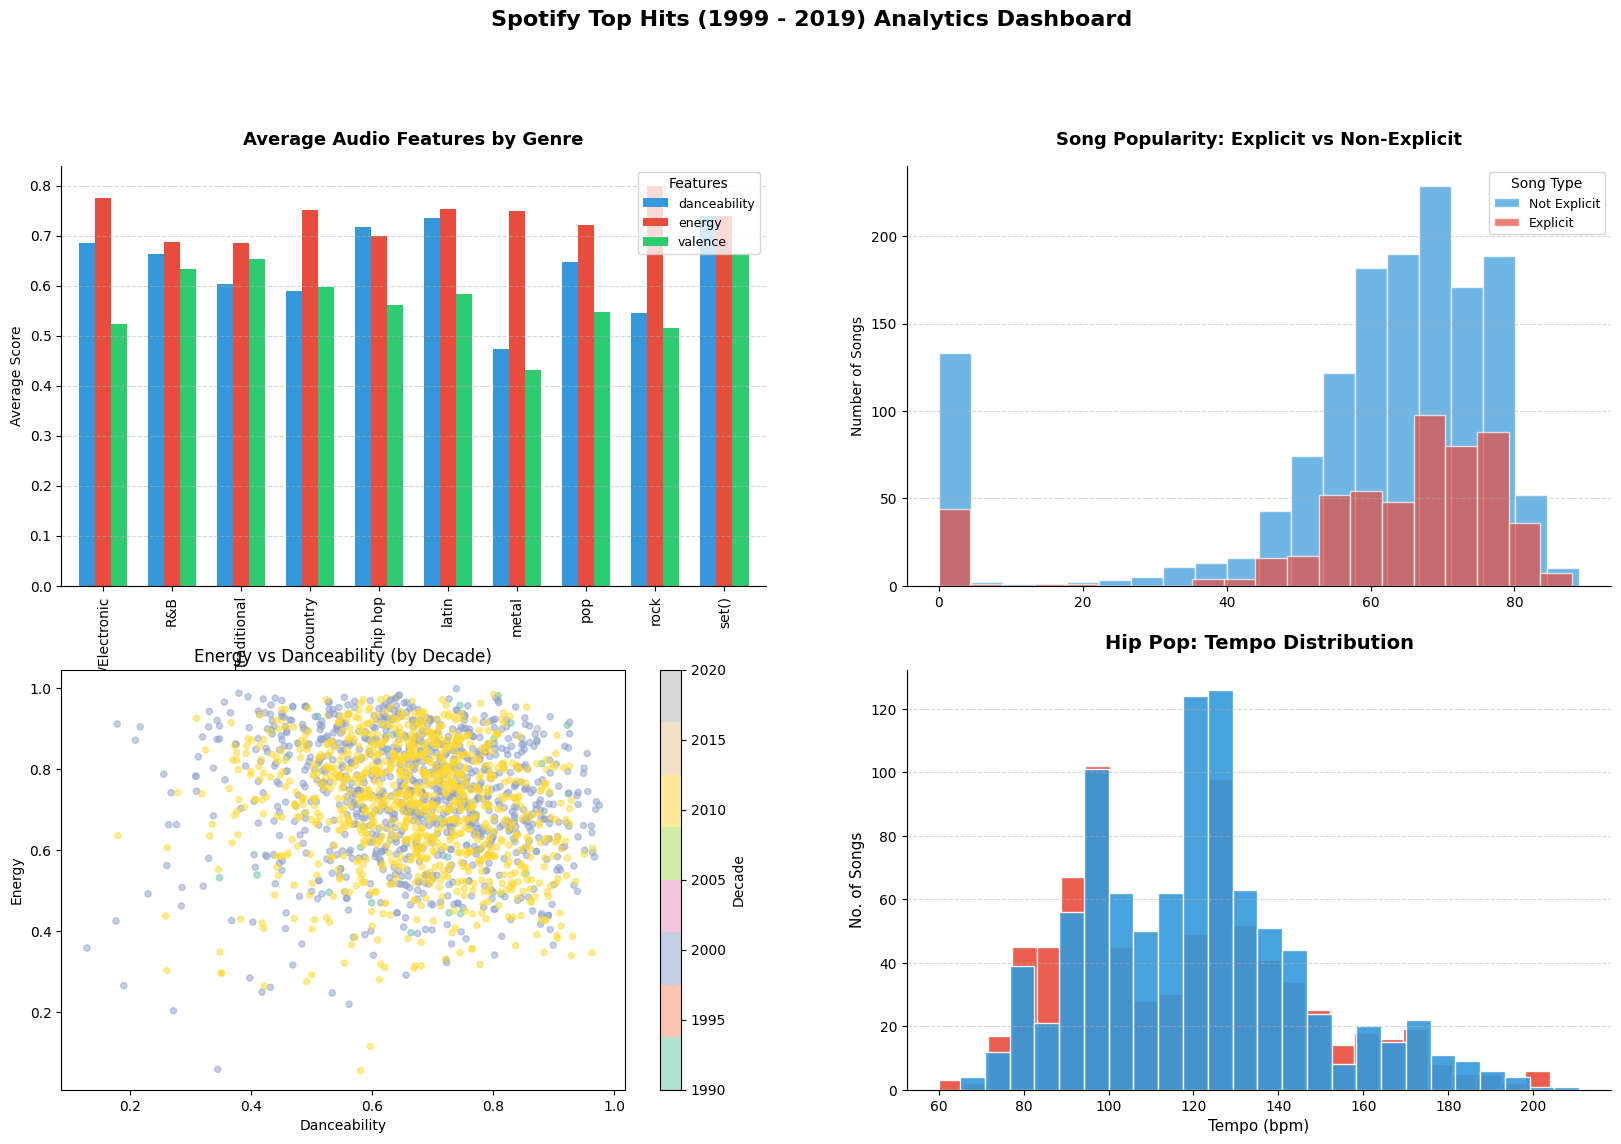

In [91]:
main()